In [229]:
using Revise
using ConjugateHeatTransfer
using CairoMakie
using LinearAlgebra
using QuadGK
using PolygonOps
using StaticArrays
using BenchmarkTools

In [230]:
# Parameters
Pe = 2;
N_laurent = 32;
N_bie = 32; # number of points per slit for BIE
solve_quad(args...) = quadgk(args...; atol=1e-10, rtol=1e-10)[1];
plot_quad(args...) = quadgk(args...; atol=1e-5, rtol=1e-5)[1];

# Bodies
zc1 = -2;
shape1(θ) = exp(im*θ) * (1 + 0.3*cos(2*θ-1) + 0.1*sin(5*θ));
temp1(θ) = 2;
b1 = DirichletBody(zc1, θ->zc1+shape1(θ), θ->temp1(θ));

zc2 = 2 - 2im;
shape2(θ) = exp(im*θ) * (1 + 0.2*sin(3*θ));
temp2(θ) = 1;
b2 = DirichletBody(zc2, θ->zc2+shape2(θ), θ->temp2(θ));

zc3 = 1 + 2im;
shape3(θ) = exp(im*θ);
temp3(θ) = 3;
b3 = DirichletBody(zc3, θ->zc3+shape3(θ), θ->temp3(θ));

bodies = [b1, b2, b3];

In [231]:
# Solve potential flow
t0 = time();
W = aaa_potential_flow(bodies, N_laurent);
println("Solved potential flow (", round(time()-t0, digits=3), " s)");
t0 = time();
reparametrize!(bodies, W; atol=1e-6);
println("Joukowsky reparametrization done (", round(time()-t0, digits=3), " s)");

N samples: 32, AAA poles: 8
N samples: 64, AAA poles: 16
N samples: 128, AAA poles: 31
N samples: 256, AAA poles: 40
N samples: 512, AAA poles: 41
N samples: 1024, AAA poles: 39
N samples: 32, AAA poles: 7
N samples: 64, AAA poles: 16
N samples: 128, AAA poles: 25
N samples: 256, AAA poles: 26
N samples: 512, AAA poles: 26
N samples: 32, AAA poles: 1
N samples: 64, AAA poles: 1
  Q shape: (972, 330)
  Fitting error: 3.730349362740526e-13
Solved potential flow (2.11 s)
  w coeffs: 62
  dθ coeffs: 1061
  zη coeffs: 395
  Tη coeffs: 1
  w coeffs: 40
  dθ coeffs: 220
  zη coeffs: 143
  Tη coeffs: 1
  w coeffs: 30
  dθ coeffs: 24
  zη coeffs: 27
  Tη coeffs: 1
Joukowsky reparametrization done (0.756 s)


In [232]:
# Panels
panels = [DirichletPanel(body) for body in bodies];
t0 = time();
solve_densities!(panels, N_bie; Pe=Pe, atol=1e-4, quadrature=solve_quad);
println("Densities solved (", round(time()-t0, digits=3), " s)");

  g coeffs: 0
  g coeffs: 0
  g coeffs: 0
size(M) = (192, 96)
cond(M) = 38.95806396432676
Densities solved (2.568 s)


In [233]:
for p in panels
    println(p.flux)
end
println("Total flux: ", sum([p.flux for p in panels]))

12.415128009275275
-0.04731953422588596
14.519498548105702
Total flux: 26.88730702315509


In [234]:
# Evaluate T(z)
gridsize = 300
Lz = 6.1
x = collect(LinRange(-Lz, Lz, gridsize));
y = collect(LinRange(-Lz, Lz, gridsize));
z = x' .+ im*y;

# Evaluate flow
t0 = time();
w = reshape(W(vec(z)), size(z));
println("Flow evaluated (", round(time()-t0, digits=3), " s)");

# Mask interiors before evaluating temperature
φ = real(w);
ψ = imag(w);
function check_inside(body, z)
    poly = body.zθ.(LinRange(0, 2π, 100))
    poly[end] = poly[1]
    poly = [[real(z), imag(z)] for z in poly]
    return inpolygon([real(z), imag(z)], poly; in=true, on=false, out=false)
end
for body in bodies
    check_body(z) = check_inside(body, z)
    interior = check_body.(z)
    φ[interior] .= -999
    ψ[interior] .= -999
end

# Evaluate temperature
t0 = time();
T = EvaluateSystem(φ, ψ, panels; Pe=Pe, quadrature=plot_quad);
println("Temperature evaluated (", round(time()-t0, digits=3), " s)");

# Mask interiors
for body in bodies
    check_body(z) = check_inside(body, z)
    interior = check_body.(z)
    φ[interior] .= NaN
    ψ[interior] .= body.ψ
    T[interior] .= NaN
end

# Evaluate in w domain
gridsize = 300
Lw = 7.1
φw = collect(LinRange(-Lw, Lw, gridsize));
ψw = collect(LinRange(-Lw, Lw, gridsize));
ww = φw' .+ im*ψw;
Tw = EvaluateSystem(real(ww), imag(ww), panels; Pe=Pe, quadrature=plot_quad);

Flow evaluated (0.261 s)
Temperature evaluated (2.017 s)


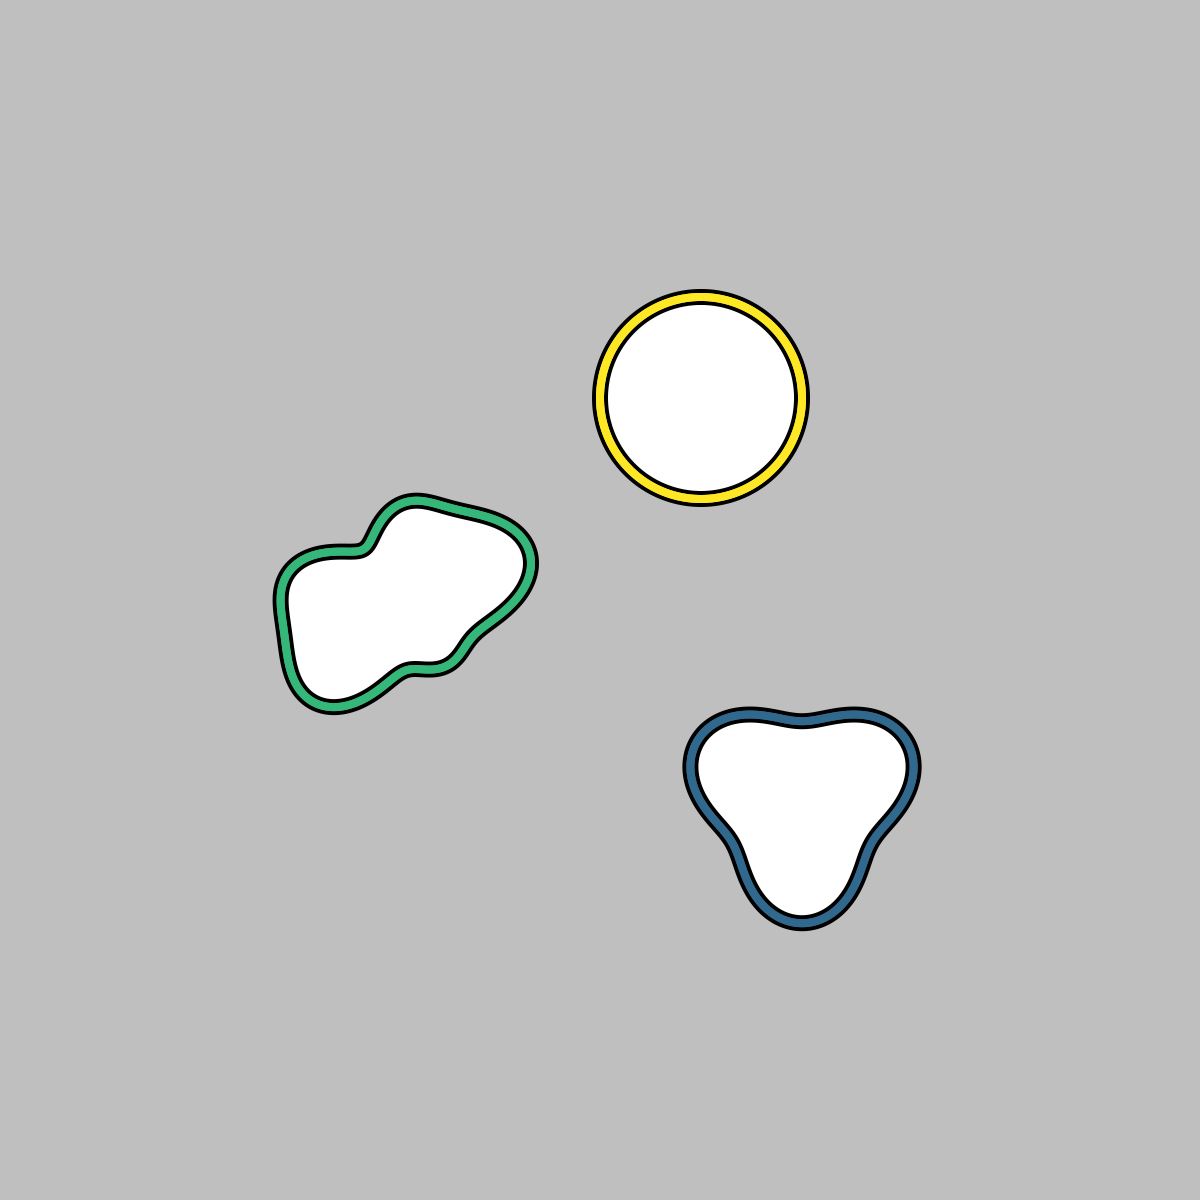

In [235]:
# Plot
gray = to_colormap(:Greys_6)[2]
set_theme!(theme_latexfonts());

# Parameters
Tmin = 0
Tmax = 3
Lz *= 0.99
Lw *= 0.99

# Right panel: T(z)
fig = Figure(size=(600, 600), figure_padding=-5);
ax = Axis(fig[1,1], aspect=DataAspect());
xlims!(ax, -Lz, Lz)
ylims!(ax, -Lz, Lz)
# Background for body interiors
poly!(ax, [(-Lz, -Lz), (Lz, -Lz), (Lz, Lz), (-Lz, Lz)], color=:white, rasterize=true)
poly!(ax, [(-Lz, -Lz), (Lz, -Lz), (Lz, Lz), (-Lz, Lz)], color=(:black,0.25), rasterize=true)
# Bodies
colorrange = (Tmin, Tmax);
θp = LinRange(0, 2π, 300);
for body in bodies
    boundary = body.zθ.(θp)
    temp = body.Tθ.(θp)
    # Fill white
    poly!(ax, real(boundary), imag(boundary), color=:white, rasterize=true)
    lines!(ax, real(boundary), imag(boundary), color=:black, linewidth=8, colorrange=colorrange)
    lines!(ax, real(boundary), imag(boundary), color=temp, linewidth=4, colorrange=colorrange)
    # Replot with shift to get rid of color artifacts
    boundary = body.zθ.(θp.+π/length(θp))
    temp = body.Tθ.(θp.+π/length(θp))
    lines!(ax, real(boundary), imag(boundary), color=temp, linewidth=4, colorrange=colorrange)
end

hidedecorations!(ax)

save("triple_z1.pdf", fig);
fig

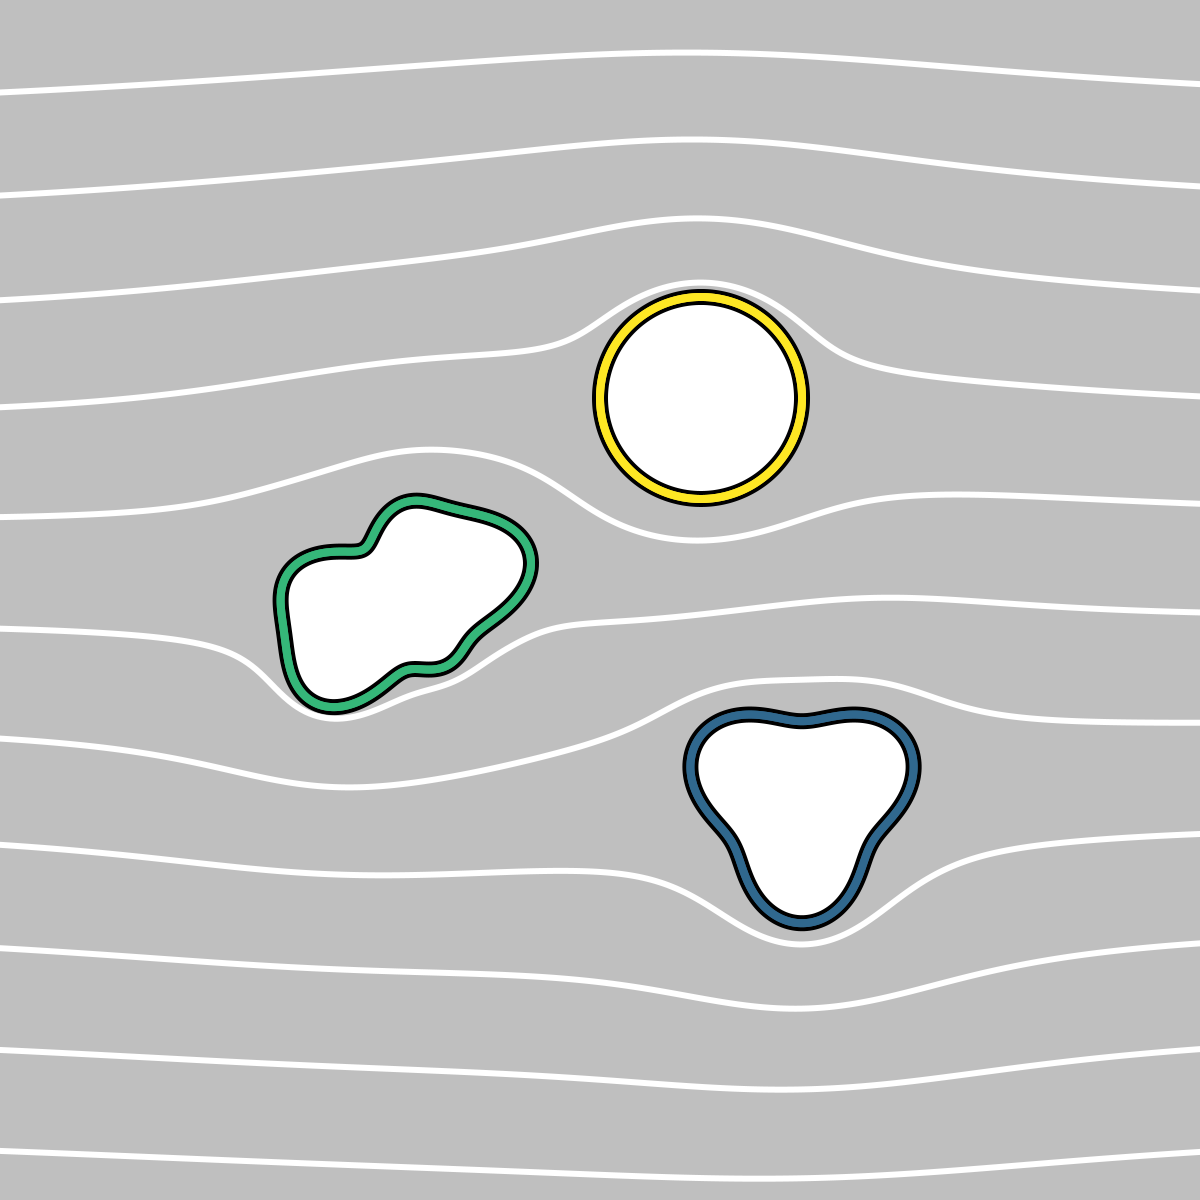

In [236]:
# Streamlines
ψ_levels = collect(-5.25:1:5)
contour!(ax, x, y, ψ', levels=ψ_levels, color=:white, linewidth=3);

save("triple_z2.pdf", fig);
fig

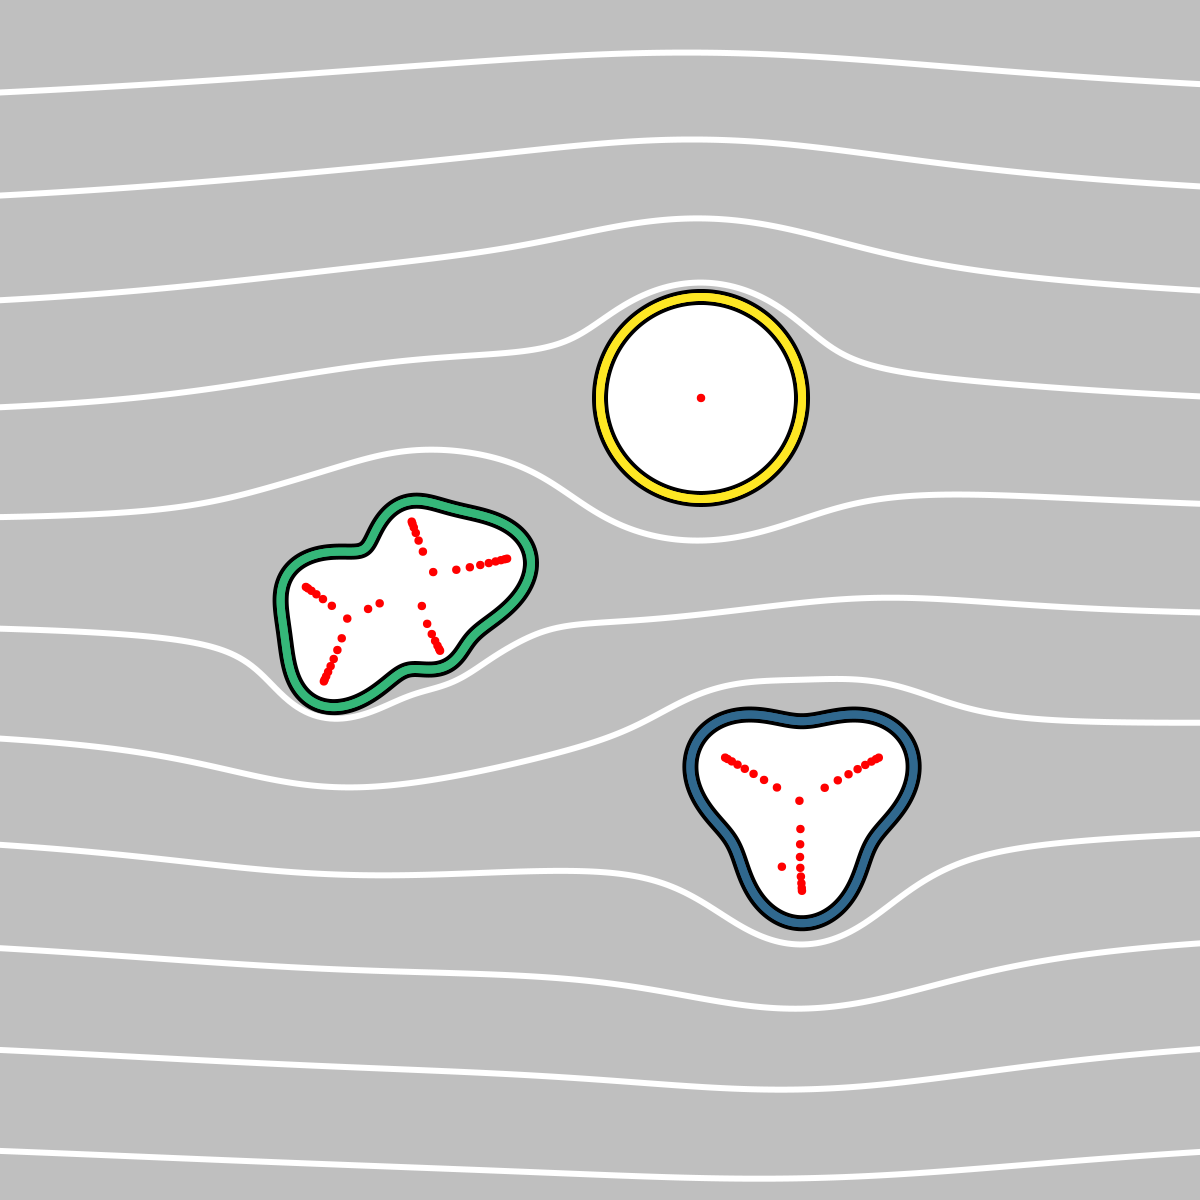

In [237]:
# AAA poles
for body in bodies
    scatter!(ax, real(body.aaa_poles), imag(body.aaa_poles), color=:red, markersize=6)
end

save("triple_z3.pdf", fig);
fig

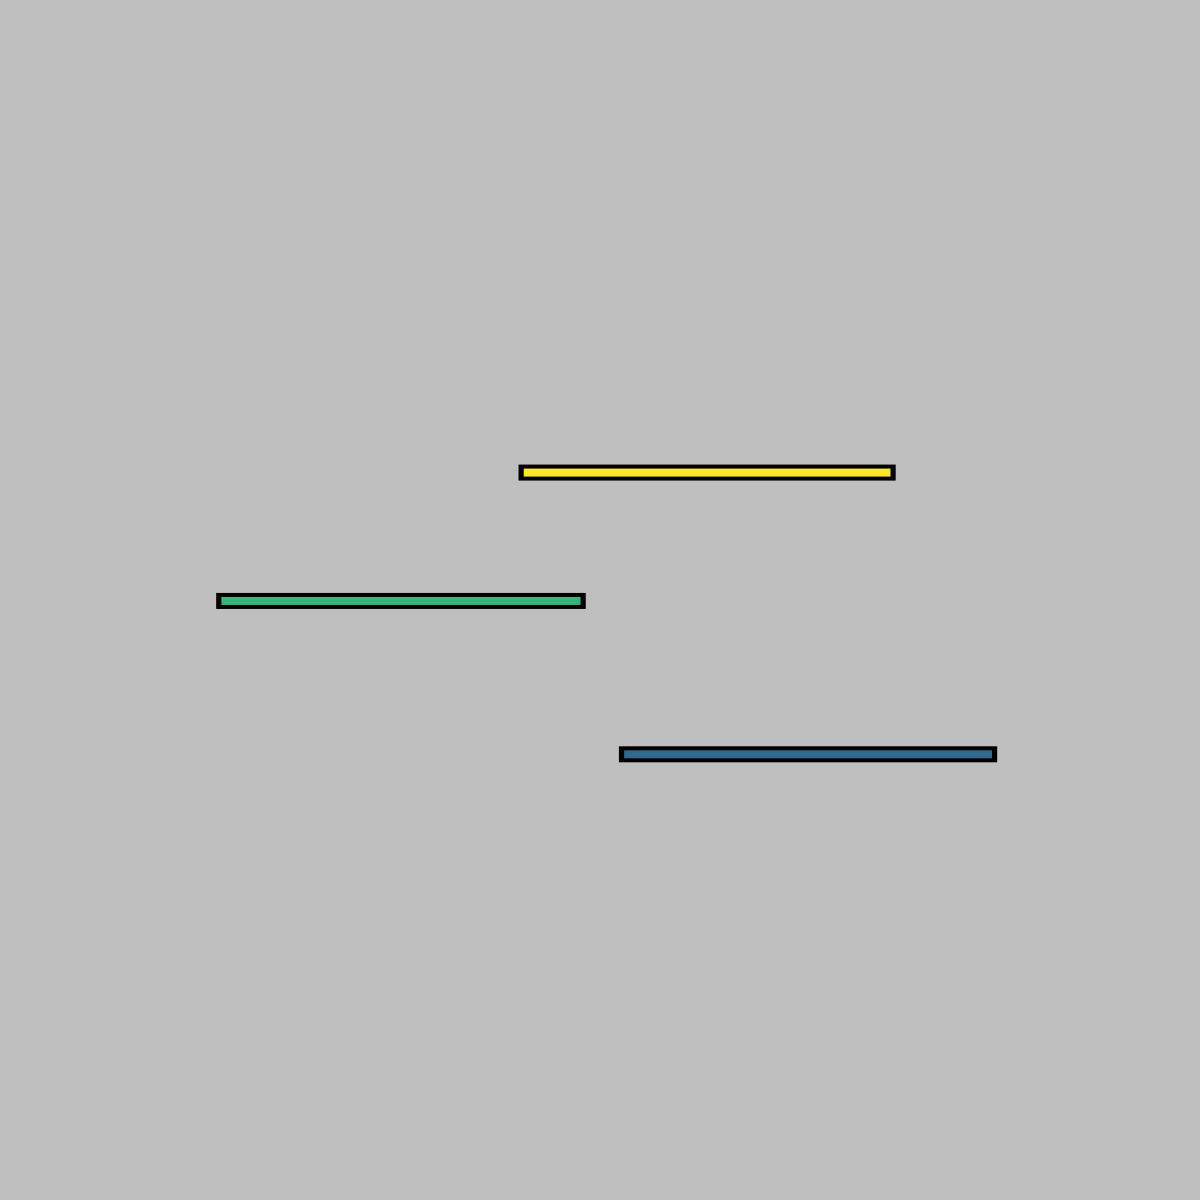

In [238]:
T_levels = LinRange(Tmin, Tmax, 16);

# Left panel: T(w)
fig = Figure(size=(600, 600), figure_padding=-5);
ax = Axis(fig[1,1], aspect=DataAspect());
xlims!(ax, -Lw, Lw)
ylims!(ax, -Lw, Lw)
# Background for body interiors
poly!(ax, [(-Lw, -Lw), (Lw, -Lw), (Lw, Lw), (-Lw, Lw)], color=:white, rasterize=true)
poly!(ax, [(-Lw, -Lw), (Lw, -Lw), (Lw, Lw), (-Lw, Lw)], color=(:black,0.25), rasterize=true)
# Body slits
for body in bodies
    temp = body.Tθ.(0)
    lines!(ax, [body.φmin-0.06, body.φmax+0.06], [body.ψ, body.ψ], color=:black, linewidth=8)
    lines!(ax, [body.φmin, body.φmax], [body.ψ, body.ψ], color=temp, colorrange=colorrange, linewidth=4)
end

hidedecorations!(ax)

save("triple_w1.pdf", fig);
fig

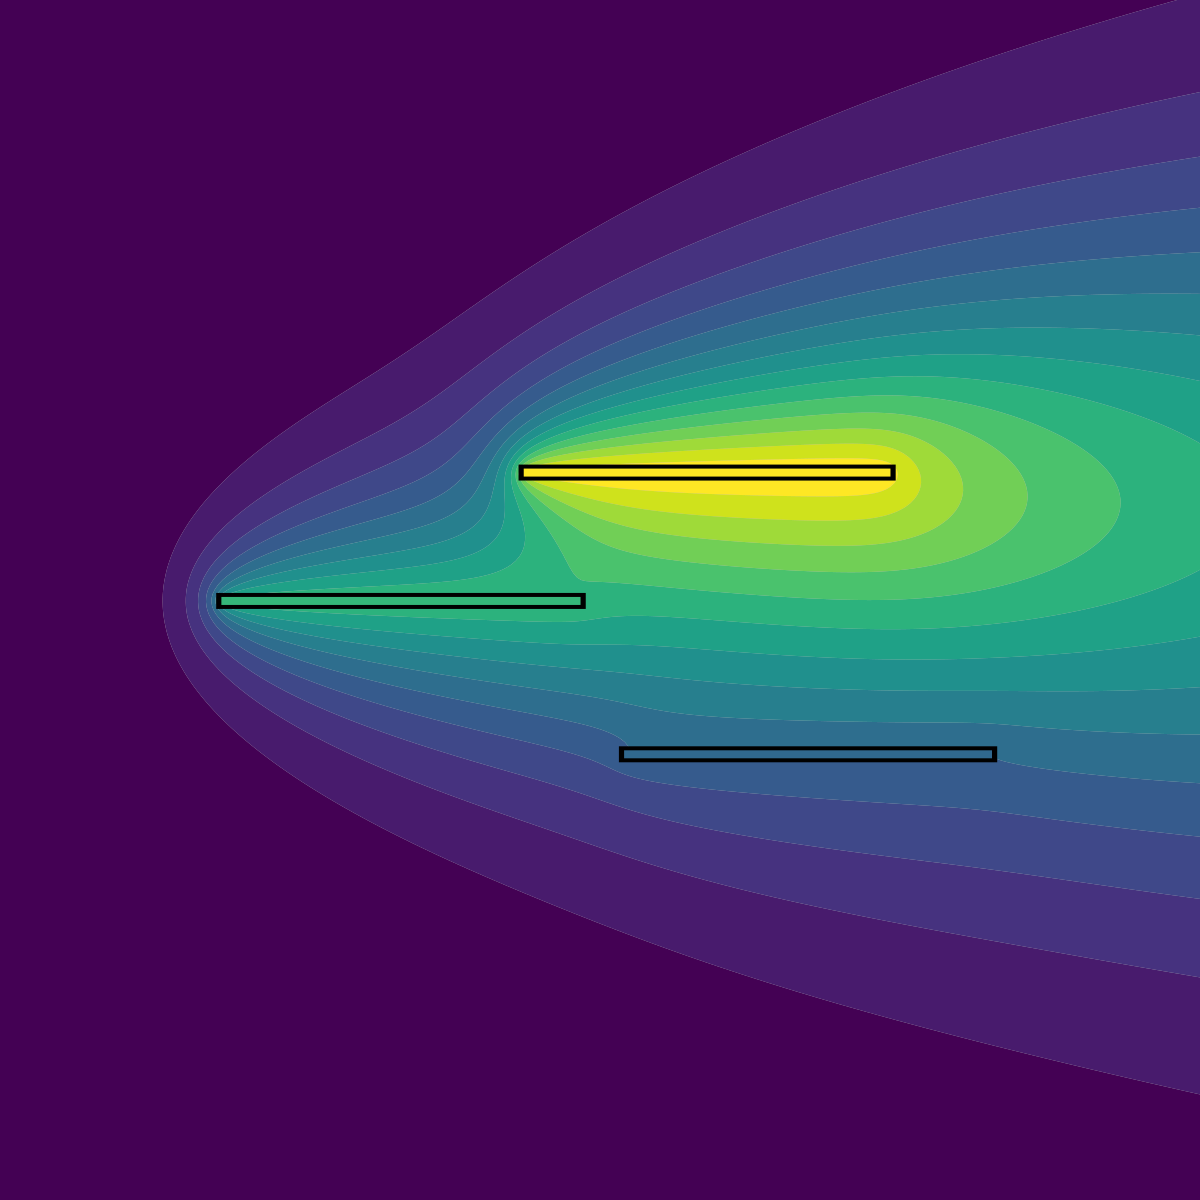

In [239]:
# Left panel: T(w)
fig = Figure(size=(600, 600), figure_padding=-5);
ax = Axis(fig[1,1], aspect=DataAspect());
xlims!(ax, -Lw, Lw)
ylims!(ax, -Lw, Lw)
# Background for body interiors
poly!(ax, [(-Lw, -Lw), (Lw, -Lw), (Lw, Lw), (-Lw, Lw)], color=:white, rasterize=true)
poly!(ax, [(-Lw, -Lw), (Lw, -Lw), (Lw, Lw), (-Lw, Lw)], color=(:black,0.25), rasterize=true)
# Temperature contours
contourf!(ax, φw, ψw, Tw', levels=T_levels, nan_color=:black);
# Body slits
for body in bodies
    temp = body.Tθ.(0)
    lines!(ax, [body.φmin-0.06, body.φmax+0.06], [body.ψ, body.ψ], color=:black, linewidth=8)
    lines!(ax, [body.φmin, body.φmax], [body.ψ, body.ψ], color=temp, colorrange=colorrange, linewidth=4)
end

hidedecorations!(ax)

save("triple_w2.pdf", fig);
fig

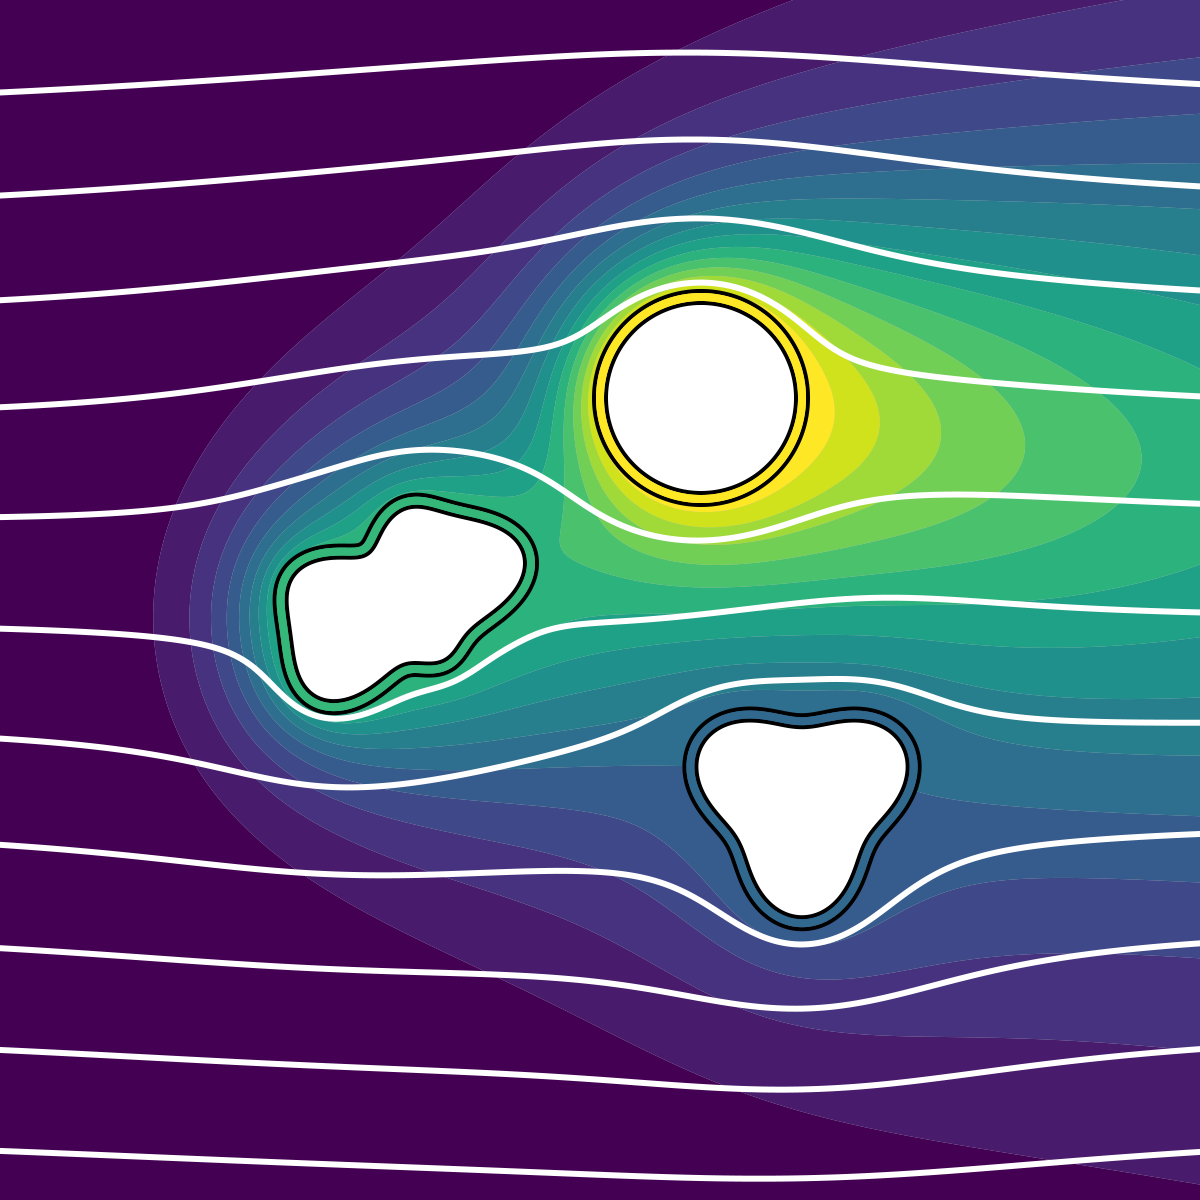

In [240]:
# Right panel: T(z)
fig = Figure(size=(600, 600), figure_padding=-5);
ax = Axis(fig[1,1], aspect=DataAspect());
xlims!(ax, -Lz, Lz)
ylims!(ax, -Lz, Lz)
# Background for body interiors
poly!(ax, [(-Lz, -Lz), (Lz, -Lz), (Lz, Lz), (-Lz, Lz)], color=:white, rasterize=true)
poly!(ax, [(-Lz, -Lz), (Lz, -Lz), (Lz, Lz), (-Lz, Lz)], color=(:black,0.25), rasterize=true)
# Temperature contours
contourf!(ax, x, y, T', levels=T_levels, nan_color=:black);
# Streamlines
ψ_levels = collect(-5.25:1:5)
contour!(ax, x, y, ψ', levels=ψ_levels, color=:white, linewidth=3);
# Bodies
colorrange = (Tmin, Tmax);
θp = LinRange(0, 2π, 300);
for body in bodies
    boundary = body.zθ.(θp)
    temp = body.Tθ.(θp)
    # Fill white
    poly!(ax, real(boundary), imag(boundary), color=:white, rasterize=true)
    lines!(ax, real(boundary), imag(boundary), color=:black, linewidth=8, colorrange=colorrange)
    lines!(ax, real(boundary), imag(boundary), color=temp, linewidth=4, colorrange=colorrange)
    # Replot with shift to get rid of color artifacts
    boundary = body.zθ.(θp.+π/length(θp))
    temp = body.Tθ.(θp.+π/length(θp))
    lines!(ax, real(boundary), imag(boundary), color=temp, linewidth=4, colorrange=colorrange)
end

hidedecorations!(ax)

save("triple_z4.pdf", fig);
fig

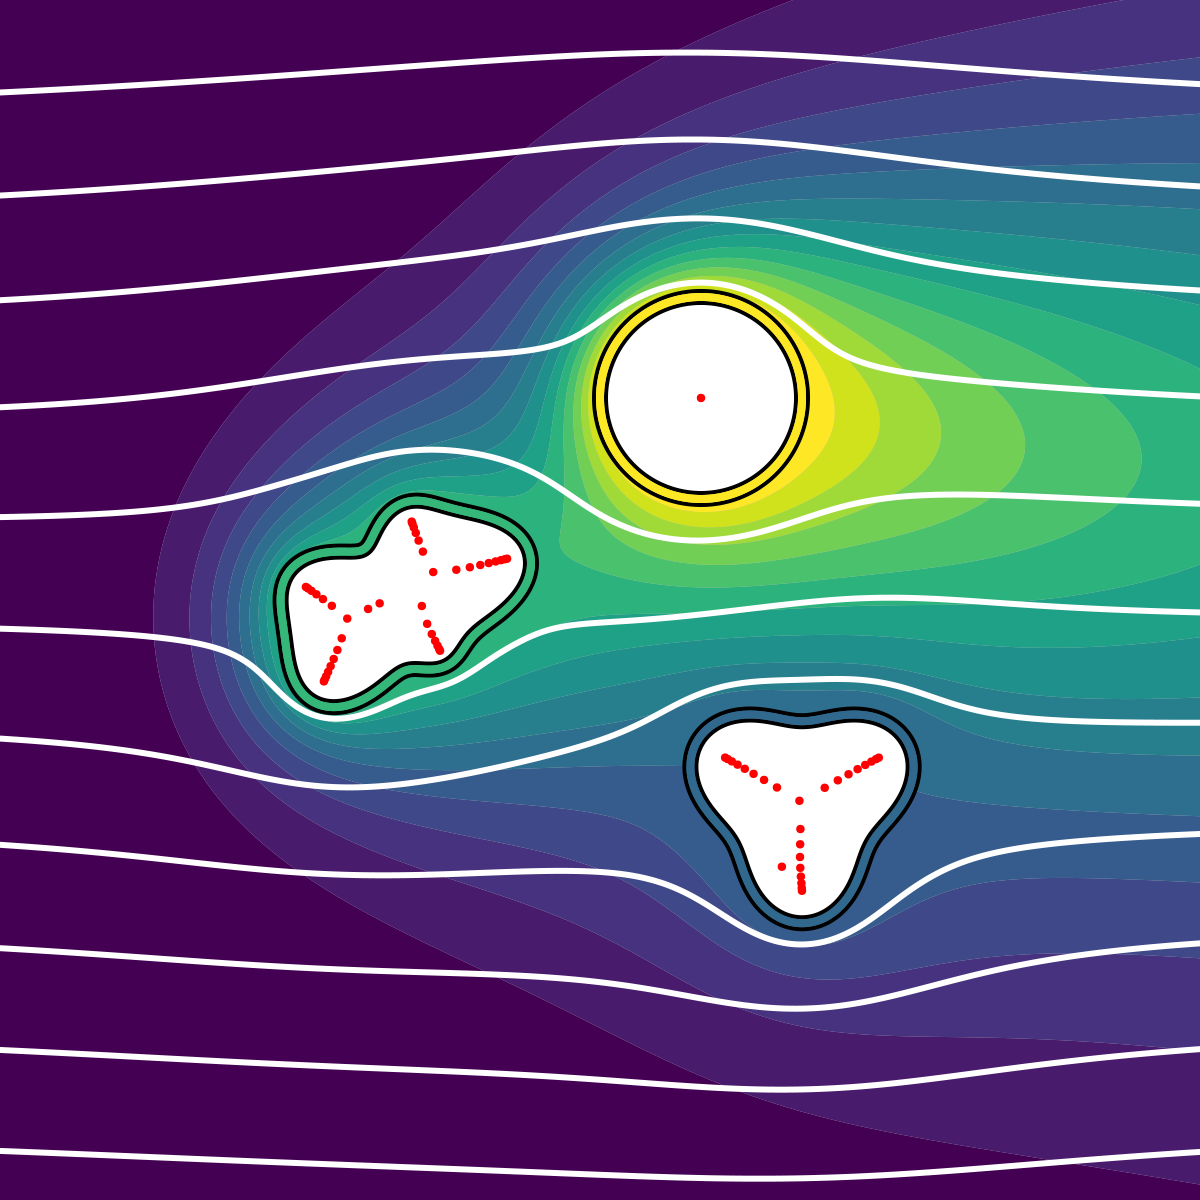

In [241]:
for body in bodies
    scatter!(ax, real(body.aaa_poles), imag(body.aaa_poles), color=:red, markersize=6)
end

save("triple_z5.pdf", fig);
fig